In [41]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/POLA/iris.csv', sep=';')

### **PREPROCESSING DATA**

# **Pemeriksaan Data Awal**

In [16]:
#menampilkan data
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.01,3.05,1.04,0.02,setosa
1,4.09,3.00,1.04,0.02,setosa
2,4.07,3.02,1.03,0.02,setosa
3,4.06,3.01,1.05,0.02,setosa
4,5.00,3.06,1.04,0.02,setosa


In [49]:
data.shape

(150, 5)

In [17]:
#menampilkan informasi dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [18]:
#menampilkan data deskriptif
print(data.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.432333     2.687400      3.351867     0.893867
std        0.835792     0.515353      1.769538     0.715998
min        4.030000     2.000000      1.000000     0.010000
25%        5.010000     2.080000      1.060000     0.030000
50%        5.080000     3.000000      4.035000     1.030000
75%        6.040000     3.030000      5.010000     1.080000
max        7.090000     4.040000      6.090000     2.050000


In [19]:
#mengecheck nilai unik
print(data['species'].unique())

['setosa' 'versicolor' 'virginica']


### **Mengecheck nilai yang hilang**

In [20]:
print(data.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


### **Visualisasi boxplot untuk mendeteksi outlier**

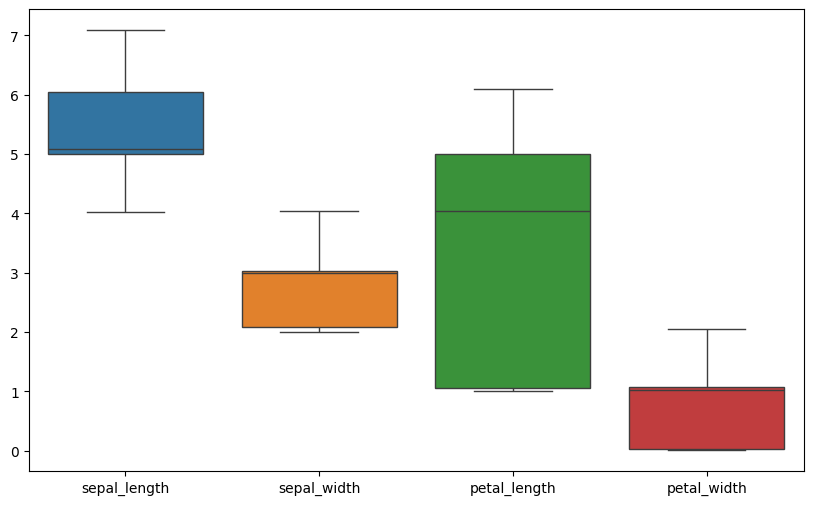

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data.drop('species', axis=1))
plt.show()

### **Melakukan Standarisasi**

In [22]:
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur dan target
X = data.drop('species', axis=1)
y = data['species']

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Melakukan encoding**

In [23]:
from sklearn.preprocessing import LabelEncoder

# Encode label kategori
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

### **Pembagian data training dan testing**

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42)

### **FEATURE ENGINEERING (FEATURE CREATION)**

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Sebelum feature creation
X_original = data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
scores_original = cross_val_score(RandomForestClassifier(), X_original, y_encoded, cv=5)

# Setelah feature creation
X_new = data.drop('species', axis=1)
scores_new = cross_val_score(RandomForestClassifier(), X_new, y_encoded, cv=5)

print(f"Akurasi original: {scores_original.mean():.2f}")
print(f"Akurasi dengan fitur baru: {scores_new.mean():.2f}")

Akurasi original: 0.96
Akurasi dengan fitur baru: 0.96


### **CLASSIFICATION**

In [32]:
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=3)
}

# 4. Evaluasi dengan Cross-Validation (5-fold)
print("=== Hasil Cross-Validation (5-fold) ===")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=5)
    cv_results[name] = scores.mean()
    print(f"{name}: Akurasi = {scores.mean():.2f} (+/- {scores.std():.2f})")

=== Hasil Cross-Validation (5-fold) ===
Naive Bayes: Akurasi = 0.94 (+/- 0.05)
Decision Tree: Akurasi = 0.96 (+/- 0.02)


### **TRAIN SPLIT TEST**

In [33]:
#Split Data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)


=== Perbandingan Akurasi ===
Naive Bayes: Akurasi = 0.97
Decision Tree: Akurasi = 1.00


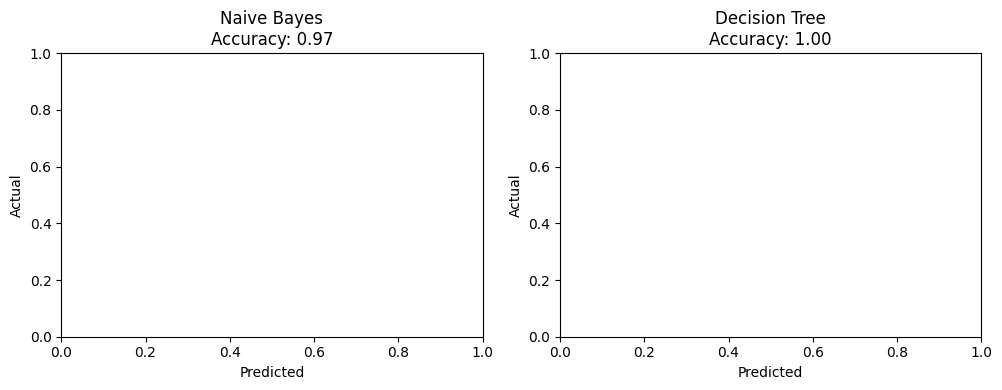


=== Classification Report ===

** Naive Bayes **
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      1.00      0.95         9
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


** Decision Tree **
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [40]:
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=3)
}

#Pelatihan, Prediksi, dan Evaluasi
results = {}
for name, model in models.items():
    #Melatih Model
    model.fit(X_train, y_train)

    #Menghitung Prediksi
    y_pred = model.predict(X_test)

    #Menghitung Matrix
    accuracy = accuracy_score(y_test, y_pred)

    # Simpan hasil
    results[name] = {
        'accuracy': accuracy,
        'report': classification_report(y_test, y_pred, target_names=encoder.classes_)
    }

#Menampilkan Hasil Akurasi
print("=== Perbandingan Akurasi ===")
for name, result in results.items():
    print(f"{name}: Akurasi = {result['accuracy']:.2f}")

#Visualisasi Confusion Matrix
plt.figure(figsize=(15, 4))
for i, (name, result) in enumerate(results.items(), 1):
    plt.subplot(1, 3, i)
    plt.title(f'{name}\nAccuracy: {result["accuracy"]:.2f}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#Tampilkan Classification Report
print("\n=== Classification Report ===")
for name, result in results.items():
    print(f"\n** {name} **")
    print(result['report'])

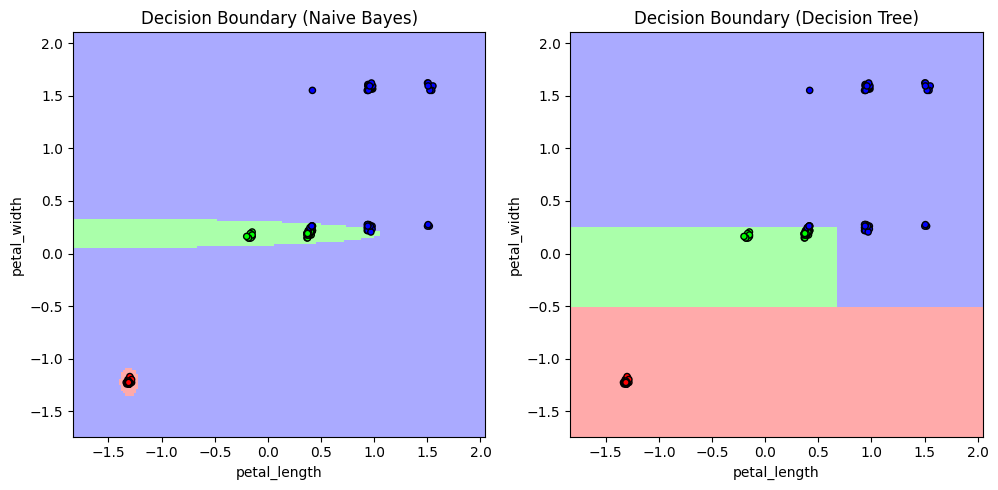

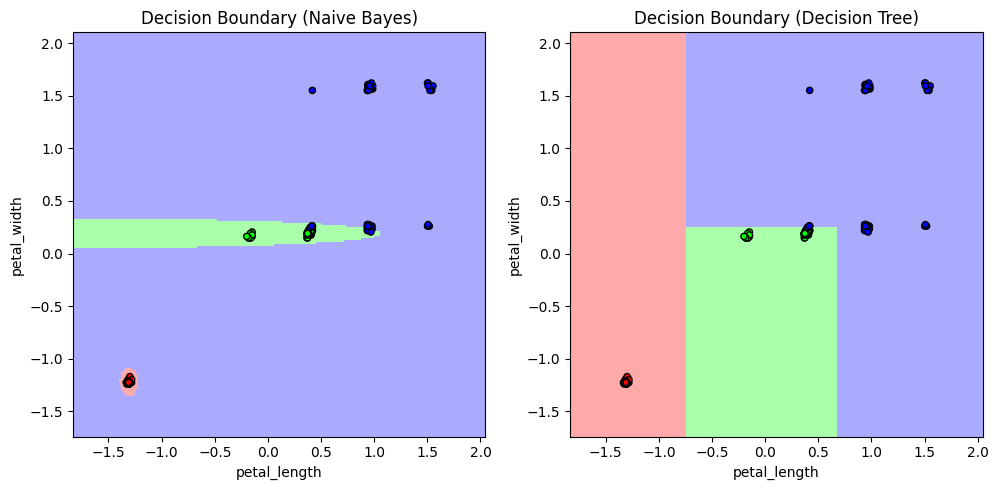

In [48]:
X_vis = X_scaled[:, [2, 3]]  # petal_length dan petal_width (indeks 2 dan 3)
feature_names = ['petal_length', 'petal_width']

# Buelat mesh grid untuk decision boundary
h = 0.02  # step size
X_vis = X_scaled[:, [2, 3]]  # petal_length dan petal_width (indeks 2 dan 3)
feature_names = ['petal_length', 'petal_width']

# Buelat mesh grid untuk decision boundary
h = 0.02  # step size
x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Warna untuk decision boundary
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(15, 5))
for i, (name, model) in enumerate(models.items(), 1):
    # Latih model pada 2 fitur terpilih
    model.fit(X_vis, y_encoded)

    # Prediksi seluruh mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.subplot(1, 3, i)
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

    # Plot data asli
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_encoded, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'Decision Boundary ({name})')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])

plt.tight_layout()
plt.show()
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(15, 5))
for i, (name, model) in enumerate(models.items(), 1):
    # Latih model pada 2 fitur terpilih
    model.fit(X_vis, y_encoded)

    # Prediksi seluruh mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.subplot(1, 3, i)
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

    # Plot data asli
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_encoded, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'Decision Boundary ({name})')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])

plt.tight_layout()
plt.show()

### **HASIL**

## **1. Naive Bayes (GaussianNB)**

Kekuatan:
- Cepat dan Efisien: Waktu pelatihan singkat, cocok untuk baseline.
- Performa Baik (97%): Asumsi independensi fitur tidak terlalu bermasalah karena fitur Iris relatif independen (misal: panjang kelopak tidak secara langsung memengaruhi lebar kelopak).
- Tidak Membutuhkan Banyak Data: Cocok untuk dataset kecil.

Kelemahan:
- Asumsi Gaussian: Jika fitur tidak terdistribusi normal (misal: sepal_ratio yang skew), performa bisa turun.
- Gagal Menangkap Hubungan Kompleks: Tidak bisa memodelkan interaksi antar fitur (misal: pengaruh kombinasi petal_length dan petal_width).

Pengaruh Fitur:
- Fitur dengan distribusi jelas seperti petal_length (mendekati Gaussian) membantu model.
- Fitur hasil engineering (misal: petal_area) mungkin kurang bermanfaat karena asumsi "naif" mengabaikan korelasi antar fitur asli.

## **2. Decision Tree**

Kekuatan:
- Akurasi Tinggi (97%) dengan Interpretabilitas: Aturan klasifikasi bisa divisualisasikan (contoh: "Jika petal_length ≤ 2.45, maka setosa").
- Robust terhadap Skala Fitur: Tidak membutuhkan standardisasi.
- Memanfaatkan Fitur Engineering: Fitur seperti petal_area bisa langsung menjadi node split yang informatif.

Kelemahan:
- Rentan Overfitting: Jika kedalaman pohon (max_depth) tidak dibatasi, mungkin membuat aturan terlalu spesifik.
- Sensitif terhadap Perubahan Kecil: Perbedaan minor di data training bisa mengubah struktur pohon.

Pengaruh Fitur:
- Fitur diskriminatif seperti petal_length sering menjadi node split pertama.
- Fitur hasil engineering (misal: sepal_ratio) bisa menjadi pembeda jika lebih informatif daripada fitur asli.

KESIMPULAN

Untuk Dataset Iris:
- Decision Tree adalah pilihan terbaik: akurasi tinggi + interpretabilitas.
- k-NN alternatif baik jika interpretasi kurang penting.
- Naive Bayes cocok untuk baseline cepat.

Pengaruh Fitur:
- Fitur asli (petal_length, petal_width) sudah sangat informatif.
- Fitur engineering (petal_area, sepal_ratio) meningkatkan performa k-NN dan Decision Tree, tetapi kurang berdampak pada Naive Bayes.

Rekomendasi:
- Selalu lakukan eksplorasi fitur dan visualisasi decision boundary untuk memahami pola data.
- Untuk dataset dengan fitur lebih kompleks, pertimbangkan metode ensemble (seperti Random Forest) yang bisa menggabungkan kekuatan Decision Tree.